In [47]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc 

# 2.1 Sequences of Fair Coin Flips Can Be Understood as Sampling the Uniform Distribution on $[0, 1]$

$n = \sum^p_{j=1}{\frac{f_j}{2^j}}$

The Minimum would be if every result $f_j = 0$ for all $j$. Therefore $n = 0$.

In [20]:
n = np.ones(16)
s = 0
for x  in range(len(n)):
    s = s + 1/(2**(x+1))
print('The Maximum would be if every result f_j =1. For p=16 his would be ',s)

The Maximum would be if every result f_j =1. For p=16 his would be  0.9999847412109375


For $p \rightarrow \infty$ we can use that we  have a geometric series: $n' = \sum\limits_{j=0}^{\infty}q^j =\frac{1}{1-q}$ with $q = 0.5$. We get $n' =2$. Since we start at $j=1$ we have $n = n'-\frac{1}{2^0} = 2-1 =1$ 

In [28]:
# Bin mir nicht sicher  ob wir wie oben n oder binäre Zahlen verwenden sollen

def coinflips_bin(flips):
    """
    Convert flips time coin toss into a binary string.
    The convert the binary string into a decimal number
    """
    result = np.random.randint(2, size=flips)
    string_result = ""
    
    for a in range(len(result)):
        
        string_result = string_result + str(result[a])
        
    decimal = int(string_result, 2) 
    
    return decimal

def coinflips_n(flips):
    """
    Convert flips into a decimal number via sum( f_j/2^j)
    """
    result = np.random.randint(2, size=flips)
    n_result = 0
    for a in range(len(result)):
        
        n_result = n_result + result[a]/2**(a+1)
    
    return n_result

S = [10**2,10**4, 10**6]


    

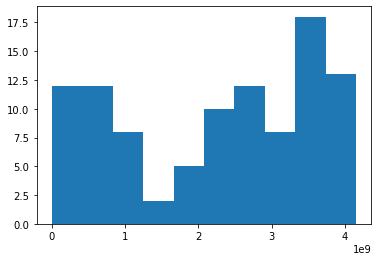

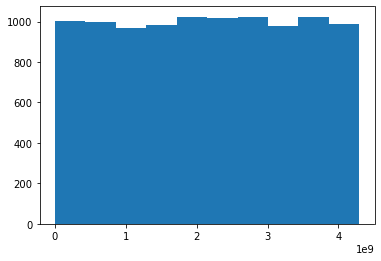

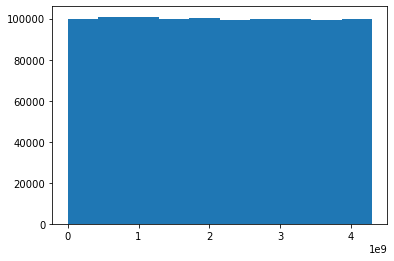

In [26]:
# ergebnis für binäre Zahlen

for sequence in range(len(S)):
    
    values = np.zeros(S[sequence])
    
    for x in range(len(values)):
        
        values[x] = coinflips_bin(32)
    
    plt.hist(values)
    plt.show()

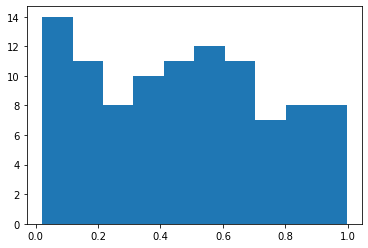

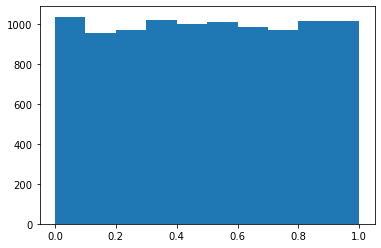

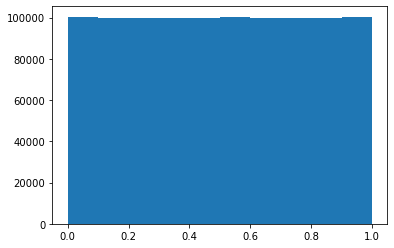

In [29]:
# ergebnis für  n
for sequence in range(len(S)):
    
    values = np.zeros(S[sequence])
    
    for x in range(len(values)):
        
        values[x] = coinflips_n(32)
    
    plt.hist(values)
    plt.show()

# 2.2 Independent Coins with Different Distributions

In [35]:
def coinflips_n_bias(flips,bias):
    """
    Convert flips into a decimal number via sum( 1/(1+e^(-bias/(2^(j+1)))))
    """
    result = np.random.randint(2, size = flips)
    n_result = 0
    for a in range(len(result)):
        
        n_result = n_result + (result[a]/(1+np.exp(-bias/(2**(a+2)))))/2**(a+1)
    
    return n_result

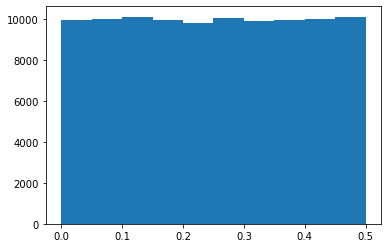

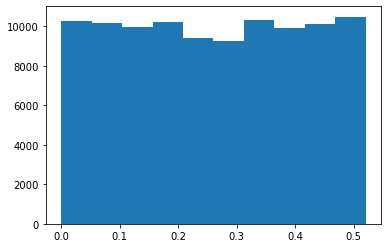

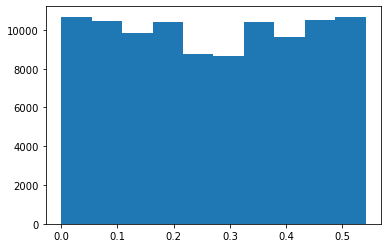

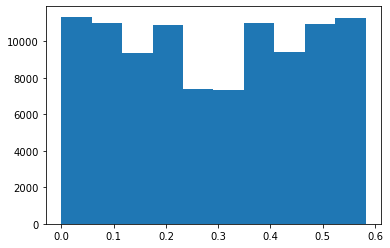

In [39]:
Bias = [0,0.5,1,2]

for lam in range(len(Bias)):
    
    values = np.zeros(10**5)
    
    for x in range(len(values)):
        
        values[x] = coinflips_n_bias(32, Bias[lam])
    
    plt.hist(values)
    plt.show()

# 2.3 Transforming CDF


$\text{CDF}_{\mu,\sigma}(x)=\int_0^X N_{\mu,\sigma} =\frac{1}{\sqrt{2\pi\sigma^2}}\int_{-\infty}^X e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

Substitute $t =\frac{x-\mu}{\sigma}$ we get $ \text{CDF}_{\mu,\sigma}(t) =\sigma \cdot \frac{1}{\sqrt{2\pi\sigma^2}}\int_{-\infty}^{(X-\mu)/\sigma} e^{-\frac{t^2}{2}} = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{(X-\mu)/\sigma} e^{-\frac{t^2}{2}} $

This is $\text{CDF}_{\mu=0,\sigma=1}$ for $[x \leq{(X-\mu)/\sigma}]$. 
The inverse CDF is given by $\text{CDF}^{-1}_{\mu=0,\sigma=1}(t) = \frac{1}{2}\left(1+ \text{erf}(\frac{t}{\sqrt{2}})\right)$

Now we resusbstitute and get $\text{CDF}^{-1}_{\mu,\sigma}(t)  = \frac{1}{2}\left(1+ \text{erf}(\frac{x-\mu}{\sqrt{2\sigma^2}})\right)$


# 2.4 Inverse Transform Sampling

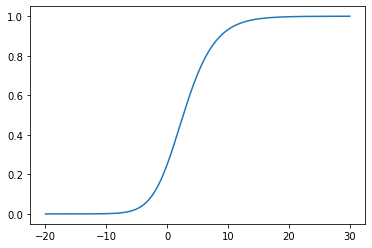

In [91]:
def CDF_logisic_squared(x):
    return ((1+np.tanh(x/6))/2)**2
            
x = np.linspace(-20,30,100000)
            
plt.plot(x,CDF_logisic_squared(x))

In [86]:
uniform_samples = np.random.uniform(low=0, high=1, size=(10**5))
preimage = np.fromiter(
    (sc.optimize.fsolve(
        lambda x: CDF_logisic_squared(x)-u,
        (0,)
    )[0] for u in uniform_samples),
    dtype=float
    )


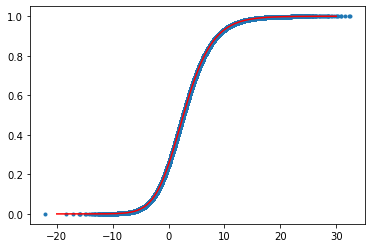

In [92]:

plt.scatter(preimage,uniform_samples, marker ='.')
plt.plot(x,CDF_logisic_squared(x), color ='red')
plt.show()

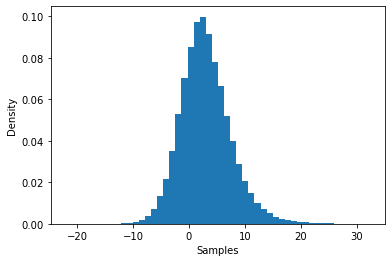

In [93]:
fig, ax = plt.subplots()
ax.hist(preimage, bins=50, density=True)
ax.set_ylabel('Density')
ax.set_xlabel('Samples')
plt.show()

$P(X)=\frac{d}{dx}\left(\frac{1+\tanh(\frac{x}{6})}{2}\right)^2 = \frac{1}{12}(\tanh(\frac{x}{6})+1)/\cosh^2(\frac{x}{6})$

In [89]:
def p_logistic(x):
    return 1/12 *(np.tanh(x/6)+1)/(np.cosh(x/6))**2

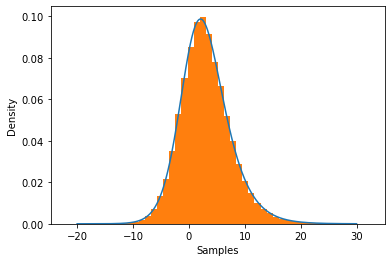

In [94]:

fig, ax = plt.subplots()
ax.plot(x,p_logistic(x))
ax.hist(preimage, bins=50, density=True)
ax.set_ylabel('Density')
ax.set_xlabel('Samples')
plt.show()